# Travel-time divergence from proximity


In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd() / "figure-reproduction", Path.cwd().parent]
repro_dir = next(
    (path.resolve() for path in candidates if (path / "src").is_dir() and (path / "data").is_dir()),
    None,
)
if repro_dir is None:
    raise FileNotFoundError("Run this notebook from the repository, figure-reproduction, or notebooks directory.")
sys.path.insert(0, str(repro_dir / "src"))

from figure_style import (
    DATA_DIR,
    OUTPUT_DIR,
    close_and_report,
    configure_style,
    figure_size,
    finish_axes,
    save_figure,
)


In [2]:
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from shapely.affinity import scale

EXPORT_PROFILE = "final"
configure_style(EXPORT_PROFILE)

travel = pd.read_parquet(DATA_DIR / "travel_time_by_home_cell.parquet")
maps = gpd.read_parquet(DATA_DIR / "spatial_temporal_bivariate_maps.geoparquet")
bin_order = [str(value) for value in range(5, 55, 5)]
travel["T_prox_bin"] = pd.Categorical(travel["T_prox_bin"], categories=bin_order, ordered=True)
grouped = travel.groupby("T_prox_bin", observed=True)
summary = grouped.agg(home_count=("home_gid9", "size"), T_prox_mean=("T_prox", "mean")).reset_index()
for metric in ["T_freq", "T_dist", "DeltaT", "DeltaT_ratio"]:
    stats = grouped[metric].agg(
        **{
            f"{metric}_mean": "mean",
            f"{metric}_p25": lambda values: values.quantile(0.25),
            f"{metric}_p75": lambda values: values.quantile(0.75),
        }
    ).reset_index()
    summary = summary.merge(stats, on="T_prox_bin", how="left")

palette = {
    (0, 0): "#bbaad3", (1, 0): "#e2e2e2", (2, 0): "#ffc575",
    (0, 1): "#705ca1", (1, 1): "#b7b7b7", (2, 1): "#f14f22",
    (0, 2): "#210f53", (1, 2): "#747474", (2, 2): "#aa0000",
}
colors = [palette[(code // 3, code % 3)] for code in range(9)]
cmap = ListedColormap(colors)
class_norm = BoundaryNorm(np.arange(-0.5, 9.5, 1), ncolors=9)
extent_quantiles = {
    "Helsinki": (0.00, 1.00), "Tampere": (0.02, 0.98),
    "Turku": (0.00, 1.00), "Oulu": (0.02, 0.98),
}
view_scale = {
    "Helsinki": (1.00, 1.00), "Tampere": (1.00, 1.00),
    "Turku": (1.00, 1.00), "Oulu": (1.75, 0.72),
}
view_shift = {
    "Helsinki": (0.00, 0.00), "Tampere": (0.00, 0.00),
    "Turku": (0.00, -0.10), "Oulu": (0.00, 0.00),
}


def set_region_view(ax, data, region):
    low, high = extent_quantiles[region]
    centroids = data.geometry.centroid
    minx, maxx = centroids.x.quantile([low, high])
    miny, maxy = centroids.y.quantile([low, high])
    xscale, yscale = view_scale[region]
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    half_width = max((maxx - minx) * xscale / 2, 1000)
    half_height = max((maxy - miny) * yscale / 2, 1000)
    dx, dy = view_shift[region]
    cx += dx * 2 * half_width
    cy += dy * 2 * half_height
    ax.set_xlim(cx - half_width * 1.03, cx + half_width * 1.03)
    ax.set_ylim(cy - half_height * 1.03, cy + half_height * 1.03)


def scaled_by_poi(data):
    result = data.copy()
    bins = np.arange(0, 5.5, 0.5)
    indices = np.clip(np.digitize(np.log1p(result["sum"].fillna(0)), bins, right=True), 0, len(bins) - 1)
    factors = np.linspace(0.55, 1.25, len(bins))[indices]
    result["geometry"] = [
        scale(geometry, xfact=float(factor), yfact=float(factor), origin="centroid")
        for geometry, factor in zip(result.geometry, factors)
    ]
    return result


def draw_map(ax, region):
    data = maps[maps["region"].eq(region)].copy()
    set_region_view(ax, data, region)
    ax.set_facecolor("#f5f5f5")
    # CartoDB basemaps will be restored after authorised API access is acquired.
    scaled_by_poi(data).plot(
        column="bivar_class", cmap=cmap, norm=class_norm,
        linewidth=0.28, edgecolor="white", alpha=0.94, zorder=5, ax=ax,
    )
    scale_bar = AnchoredSizeBar(
        ax.transData, 5_000, "5 km", loc="lower left", pad=0.25,
        borderpad=0.55, sep=2, size_vertical=120, color="#222222", frameon=True,
        fontproperties=mpl.font_manager.FontProperties(family="Arial", size=5),
    )
    scale_bar.patch.set_facecolor("white")
    scale_bar.patch.set_edgecolor("none")
    scale_bar.patch.set_alpha(0.80)
    scale_bar.set_zorder(20)
    ax.add_artist(scale_bar)
    ax.set_axis_off()


rendered pixels: 709 x 709
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/travel_time_by_proximity.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/travel_time_by_proximity.pdf


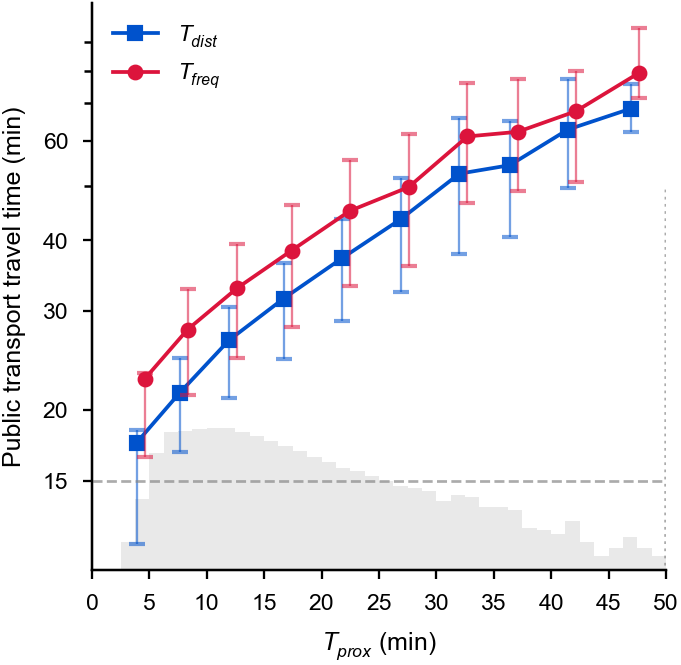

In [3]:
fig, ax = plt.subplots(figsize=figure_size("travel_time_comparison"))
fig.subplots_adjust(left=0.16, right=0.97, bottom=0.15, top=0.95)
hist_ax = ax.twinx()
counts, _, _ = hist_ax.hist(
    travel["T_prox"], bins=40, range=(0, 50), color="#aaaaaa", alpha=0.25, zorder=0
)
hist_ax.set_yscale("log")
hist_ax.set_ylim(1, max(counts.max() ** 4, 2))
hist_ax.set_yticks([])
hist_ax.spines["right"].set_visible(False)
hist_ax.spines["top"].set_visible(False)

for metric, label, color, marker, x_offset in [
    ("T_dist", r"$T_{dist}$", "#0052CC", "s", -0.35),
    ("T_freq", r"$T_{freq}$", "#DC143C", "o", 0.35),
]:
    means = summary[f"{metric}_mean"]
    x_values = summary["T_prox_mean"] + x_offset
    errors = [
        np.abs(means - summary[f"{metric}_p25"]),
        np.abs(summary[f"{metric}_p75"] - means),
    ]
    ax.plot(x_values, means, color=color, marker=marker, markersize=2.8, label=label)
    ax.errorbar(
        x_values, means, yerr=errors, fmt="none",
        color=color, linewidth=0.55, capsize=2, alpha=0.55,
    )
ax.set_yscale("log")
ax.set_yticks([10, 15, 20, 30, 40, 60])
ax.set_yticklabels(["10", "15", "20", "30", "40", "60"])
ax.set_xlim(0, 50)
ax.set_xticks(np.arange(0, 51, 5))
ax.axhline(15, color="#888888", linestyle="--", linewidth=0.65, alpha=0.7)
ax.plot([0, 50], [0, 50], color="#888888", linestyle=":", linewidth=0.65, alpha=0.7)
ax.set_xlabel(r"$T_{prox}$ (min)")
ax.set_ylabel("Public transport travel time (min)")
ax.legend(frameon=False, loc="upper left")
ax.set_zorder(hist_ax.get_zorder() + 1)
ax.patch.set_visible(False)
paths = save_figure(fig, "travel_time_by_proximity", EXPORT_PROFILE)
close_and_report(fig, paths)


In [4]:
def draw_bar_panel(metric, color, ylabel, size_name, stem):
    fig, ax = plt.subplots(figsize=figure_size(size_name))
    fig.subplots_adjust(left=0.20, right=0.97, bottom=0.24, top=0.96)
    x = np.arange(len(summary))
    means = summary[f"{metric}_mean"]
    errors = [
        np.abs(means - summary[f"{metric}_p25"]),
        np.abs(summary[f"{metric}_p75"] - means),
    ]
    ax.bar(x, means, width=0.52, color=color, alpha=0.8)
    ax.errorbar(
        x, means, yerr=errors, fmt="none", color=color,
        linewidth=0.75, capsize=2, alpha=0.6,
    )
    ax.axhline(0, color="#222222", linewidth=0.55)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(summary["T_prox_bin"].astype(str), rotation=45, ha="right")
    ax.set_xlabel(r"$T_{prox}$ (min)")
    paths = save_figure(fig, stem, EXPORT_PROFILE)
    close_and_report(fig, paths)


1 extra bytes in post.stringData array


rendered pixels: 709 x 354
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/absolute_travel_time_difference.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/absolute_travel_time_difference.pdf


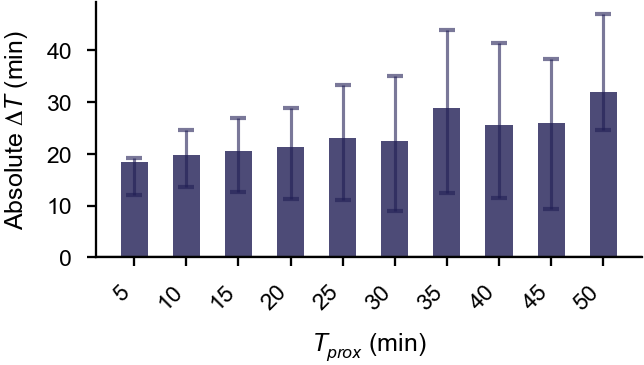

In [5]:
draw_bar_panel("DeltaT", "#211E55", r"Absolute $\Delta T$ (min)", "absolute_travel_time_difference", "absolute_travel_time_difference")


1 extra bytes in post.stringData array


rendered pixels: 709 x 354
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/relative_travel_time_difference.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/relative_travel_time_difference.pdf


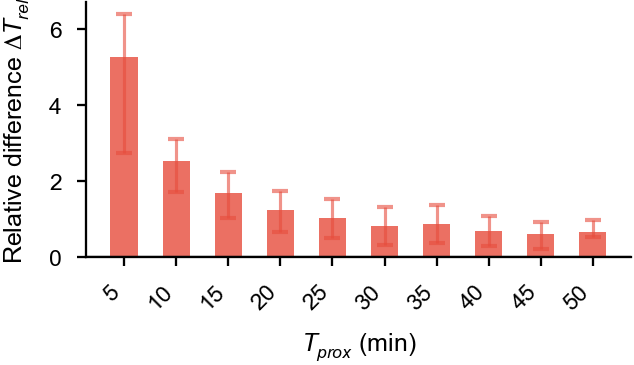

In [6]:
draw_bar_panel("DeltaT_ratio", "#E74C3C", r"Relative difference $\Delta T_{rel}$", "relative_travel_time_difference", "relative_travel_time_difference")


## Bivariate maps


In [7]:
def draw_map_panel(region, stem):
    fig, ax = plt.subplots(figsize=figure_size("spatial_temporal_map"))
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98)
    draw_map(ax, region)
    paths = save_figure(fig, stem, EXPORT_PROFILE)
    close_and_report(fig, paths)


rendered pixels: 709 x 531
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_helsinki.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_helsinki.pdf


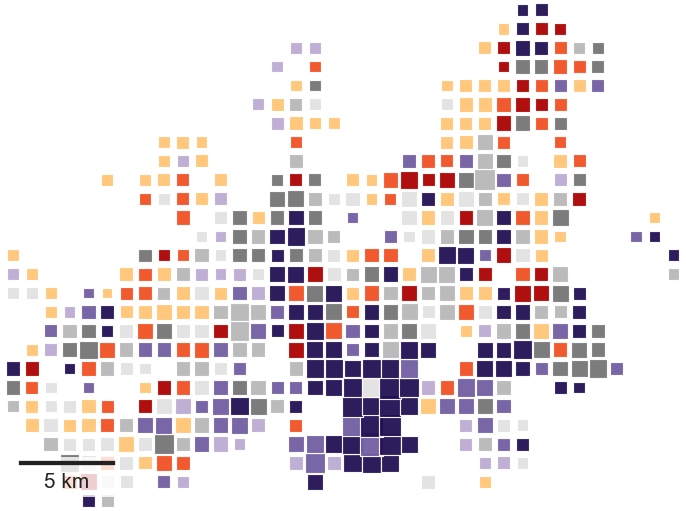

In [8]:
draw_map_panel("Helsinki", "spatial_temporal_divergence_helsinki")


rendered pixels: 709 x 531
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_tampere.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_tampere.pdf


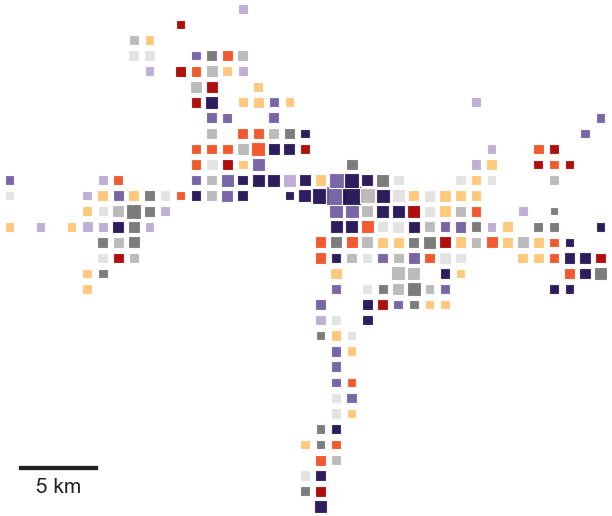

In [9]:
draw_map_panel("Tampere", "spatial_temporal_divergence_tampere")


rendered pixels: 709 x 531
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_turku.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_turku.pdf


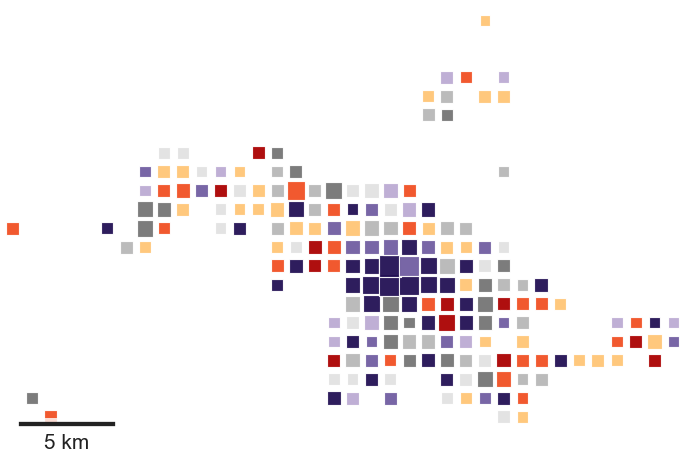

In [10]:
draw_map_panel("Turku", "spatial_temporal_divergence_turku")


rendered pixels: 709 x 531
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_oulu.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_oulu.pdf


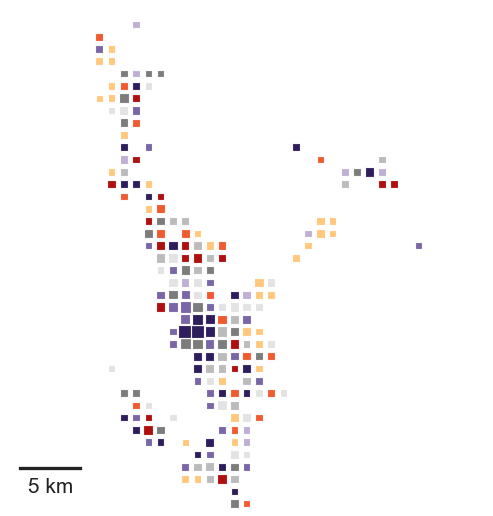

In [11]:
draw_map_panel("Oulu", "spatial_temporal_divergence_oulu")


1 extra bytes in post.stringData array


rendered pixels: 354 x 354
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_legend.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/spatial_temporal_divergence_legend.pdf


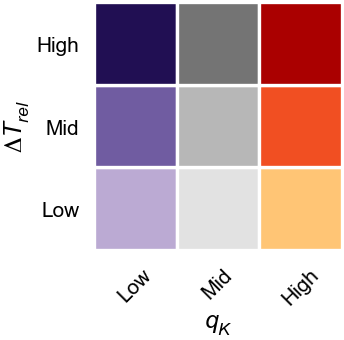

In [12]:
fig, legend_ax = plt.subplots(figsize=figure_size("spatial_temporal_legend"))
fig.subplots_adjust(left=0.26, right=0.96, bottom=0.24, top=0.96)
for qk_bin in range(3):
    for dt_bin in range(3):
        legend_ax.add_patch(
            plt.Rectangle(
                (qk_bin, dt_bin), 1, 1,
                facecolor=palette[(qk_bin, dt_bin)], edgecolor="white", linewidth=0.8,
            )
        )
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_aspect("equal")
legend_ax.set_xticks([0.5, 1.5, 2.5], ["Low", "Mid", "High"], rotation=45)
legend_ax.set_yticks([0.5, 1.5, 2.5], ["Low", "Mid", "High"])
legend_ax.set_xlabel(r"$q_K$", labelpad=1)
legend_ax.set_ylabel(r"$\Delta T_{rel}$", labelpad=1)
legend_ax.tick_params(length=0, labelsize=5)
for spine in legend_ax.spines.values():
    spine.set_visible(False)

paths = save_figure(fig, "spatial_temporal_divergence_legend", EXPORT_PROFILE)
close_and_report(fig, paths)
